<a href="https://colab.research.google.com/github/nadakhatib/Traffic-Accident-Severity-Prediction/blob/main/Traffic_Accident_Severity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Traffic Accident Severity Prediction :**

**PART 1: Install and Import Libraries**

In [1]:
# Install required libraries
!pip install kagglehub -q
!pip install pyarrow -q
!pip install xgboost -q

print("All libraries installed successfully!")

# Import libraries
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries installed successfully!
All libraries imported successfully!


**PART 2: Load Dataset from Kaggle**

In [3]:
print("\n" + "="*60)
print("LOADING DATASET FROM KAGGLE")
print("="*60)

print("Downloading US Accidents dataset...")
print("This may take a few minutes...")

# Download the dataset
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print(f"Dataset downloaded! Path: {path}")

# Find and load the CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f"CSV files found: {csv_files}")

if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])

    # Read only first 100,000 rows for faster processing
    print("\nReading CSV file (first 100,000 rows)...")
    df = pd.read_csv(csv_file_path, nrows=100000, low_memory=False)

    print(f"\nDataset loaded successfully!")
    print(f"Total records: {len(df):,}")
    print(f"Total columns: {len(df.columns)}")
    print(f"\nFirst 5 rows:")
    print(df.head())

    print("\nDataset Info:")
    print(df.info())
else:
    print("No CSV file found!")
    exit()


LOADING DATASET FROM KAGGLE
This may take a few minutes...
Using Colab cache for faster access to the 'us-accidents' dataset.
Dataset downloaded! Path: /kaggle/input/us-accidents
CSV files found: ['US_Accidents_March23.csv']

Reading CSV file (first 100,000 rows)...

Dataset loaded successfully!
Total records: 100,000
Total columns: 46

First 5 rows:
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      Fal

**PART 3: Data Sampling**

In [4]:
print("\n" + "="*60)
print("DATA SAMPLING")
print("="*60)

# If dataset is still large, take a random sample
if len(df) > 50000:
    sample_size = 50000
    df_sample = df.sample(n=sample_size, random_state=42)
    print(f"Using sample of {sample_size:,} records from {len(df):,}")
else:
    df_sample = df
    print(f"Using all {len(df):,} records")

print(f"Sample shape: {df_sample.shape}")


DATA SAMPLING
Using sample of 50,000 records from 100,000
Sample shape: (50000, 46)


**PART 4: Data Cleaning and Preprocessing**

In [5]:
print("\n" + "="*60)
print("DATA CLEANING AND PREPROCESSING")
print("="*60)

# 4.1 Select important features
selected_columns = [
    'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition',
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
    'Sunrise_Sunset'
]

# Check available columns
available_columns = [col for col in selected_columns if col in df_sample.columns]
missing_columns = [col for col in selected_columns if col not in df_sample.columns]

print(f"Selected columns: {len(selected_columns)}")
print(f"Available in dataset: {len(available_columns)}")
if missing_columns:
    print(f"Missing columns: {missing_columns}")

# Keep only available columns
df_clean = df_sample[available_columns].copy()
print(f"Data shape after column selection: {df_clean.shape}")

# 4.2 Handle datetime features
print("\nProcessing datetime features...")
try:
    df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'])
    df_clean['End_Time'] = pd.to_datetime(df_clean['End_Time'])

    # Extract time-based features
    df_clean['Hour'] = df_clean['Start_Time'].dt.hour
    df_clean['DayOfWeek'] = df_clean['Start_Time'].dt.dayofweek
    df_clean['Month'] = df_clean['Start_Time'].dt.month
    df_clean['Year'] = df_clean['Start_Time'].dt.year

    # Calculate accident duration in minutes
    df_clean['Duration_Minutes'] = (df_clean['End_Time'] - df_clean['Start_Time']).dt.total_seconds() / 60

    # Create peak hour feature
    df_clean['Is_Peak_Hour'] = df_clean['Hour'].apply(
        lambda x: 1 if (x >= 7 and x <= 9) or (x >= 16 and x <= 18) else 0
    )

    # Drop original datetime columns
    df_clean = df_clean.drop(['Start_Time', 'End_Time'], axis=1)
    print("Time-based features extracted successfully!")
except Exception as e:
    print(f"Warning: Could not process datetime columns: {e}")

print(f"Data shape after feature engineering: {df_clean.shape}")

# 4.3 Handle missing values
print("\nHandling missing values...")
missing_values = df_clean.isnull().sum()
print(f"Missing values before handling:\n{missing_values[missing_values > 0]}")

# Fill numeric missing values with column mean
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# Fill categorical missing values with mode
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Missing values after handling: {df_clean.isnull().sum().sum()}")

# 4.4 Encode categorical variables
print("\nEncoding categorical variables...")
le = LabelEncoder()
for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        print(f"  - {col}: Encoded")

print(f"\nFinal data shape: {df_clean.shape}")
print("\nFirst 5 rows of cleaned data:")
print(df_clean.head())


DATA CLEANING AND PREPROCESSING
Selected columns: 26
Available in dataset: 26
Data shape after column selection: (50000, 26)

Processing datetime features...
Time-based features extracted successfully!
Data shape after feature engineering: (50000, 30)

Handling missing values...
Missing values before handling:
Temperature(F)         800
Humidity(%)            941
Pressure(in)           628
Visibility(mi)         905
Wind_Speed(mph)      11842
Precipitation(in)    46298
Weather_Condition      807
dtype: int64
Missing values after handling: 0

Encoding categorical variables...
  - Weather_Condition: Encoded
  - Sunrise_Sunset: Encoded

Final data shape: (50000, 30)

First 5 rows of cleaned data:
       Severity  Start_Lat   Start_Lng  Temperature(F)  Humidity(%)  \
75721         2  34.027828 -118.211700            62.1         53.0   
80184         3  33.937790 -117.556152            91.9         26.0   
19864         3  38.553600 -121.690643            66.2         52.0   
76699       

**PART 5: Feature-Target Split and Scaling**

In [6]:
print("\n" + "="*60)
print("FEATURE-TARGET SPLIT AND SCALING")
print("="*60)

# Separate features and target
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity']

print(f"Number of features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled successfully!")

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]:,} records")
print(f"Testing set: {X_test.shape[0]:,} records")


FEATURE-TARGET SPLIT AND SCALING
Number of features: 29
Target distribution:
Severity
1       49
2    27427
3    22509
4       15
Name: count, dtype: int64
Features scaled successfully!

Training set: 40,000 records
Testing set: 10,000 records


**PART 6: Model 1 - Random Forest Classifier**

In [7]:
print("\n" + "="*60)
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("="*60)

# Initialize and train
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nRandom Forest Performance:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\nConfusion Matrix:\n{cm_rf}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rf)}")


MODEL 1: RANDOM FOREST CLASSIFIER
Training Random Forest model...

Random Forest Performance:
Accuracy:  0.7697
Precision: 0.7807
Recall:    0.7697
F1-Score:  0.7694

Confusion Matrix:
[[   0    6    4    0]
 [   0 3908 1577    0]
 [   0  713 3789    0]
 [   0    1    2    0]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.84      0.71      0.77      5485
           3       0.71      0.84      0.77      4502
           4       0.00      0.00      0.00         3

    accuracy                           0.77     10000
   macro avg       0.39      0.39      0.39     10000
weighted avg       0.78      0.77      0.77     10000



**PART 7: Model 2 - XGBoost Classifier (FIXED)**

In [8]:
print("\n" + "="*60)
print("MODEL 2: XGBOOST CLASSIFIER")
print("="*60)

# Convert labels to start from 0 (XGBoost requirement)
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# Initialize and train
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

print("Training XGBoost model...")
xgb_model.fit(X_train, y_train_xgb)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)

# Convert predictions back to original scale (1-4)
y_pred_xgb_original = y_pred_xgb + 1

# Evaluate using original labels
xgb_accuracy = accuracy_score(y_test, y_pred_xgb_original)
xgb_precision = precision_score(y_test, y_pred_xgb_original, average='weighted')
xgb_recall = recall_score(y_test, y_pred_xgb_original, average='weighted')
xgb_f1 = f1_score(y_test, y_pred_xgb_original, average='weighted')

print(f"\nXGBoost Performance:")
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb_original)
print(f"\nConfusion Matrix:\n{cm_xgb}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_xgb_original)}")


MODEL 2: XGBOOST CLASSIFIER
Training XGBoost model...

XGBoost Performance:
Accuracy:  0.8980
Precision: 0.8987
Recall:    0.8980
F1-Score:  0.8976

Confusion Matrix:
[[   0    9    1    0]
 [   0 4837  648    0]
 [   0  359 4143    0]
 [   0    0    3    0]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.93      0.88      0.90      5485
           3       0.86      0.92      0.89      4502
           4       0.00      0.00      0.00         3

    accuracy                           0.90     10000
   macro avg       0.45      0.45      0.45     10000
weighted avg       0.90      0.90      0.90     10000



**PART 8: Model 3 - Neural Network (MLP)**

In [9]:
print("\n" + "="*60)
print("MODEL 3: NEURAL NETWORK (MLP)")
print("="*60)

# Initialize and train
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

print("Training Neural Network model...")
print("This may take a few minutes...")
nn_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nn = nn_model.predict(X_test)

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn, average='weighted')
nn_recall = recall_score(y_test, y_pred_nn, average='weighted')
nn_f1 = f1_score(y_test, y_pred_nn, average='weighted')

print(f"\nNeural Network Performance:")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1-Score:  {nn_f1:.4f}")

cm_nn = confusion_matrix(y_test, y_pred_nn)
print(f"\nConfusion Matrix:\n{cm_nn}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_nn)}")


MODEL 3: NEURAL NETWORK (MLP)
Training Neural Network model...
This may take a few minutes...

Neural Network Performance:
Accuracy:  0.6147
Precision: 0.6161
Recall:    0.6147
F1-Score:  0.6150

Confusion Matrix:
[[   0    9    1    0]
 [   0 3435 2050    0]
 [   0 1790 2712    0]
 [   0    1    2    0]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.66      0.63      0.64      5485
           3       0.57      0.60      0.59      4502
           4       0.00      0.00      0.00         3

    accuracy                           0.61     10000
   macro avg       0.31      0.31      0.31     10000
weighted avg       0.62      0.61      0.62     10000



**PART 9: Performance Comparison Table**

In [10]:
print("\n" + "="*60)
print("PERFORMANCE COMPARISON TABLE")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Neural Network'],
    'Accuracy': [rf_accuracy, xgb_accuracy, nn_accuracy],
    'Precision (weighted)': [rf_precision, xgb_precision, nn_precision],
    'Recall (weighted)': [rf_recall, xgb_recall, nn_recall],
    'F1-Score (weighted)': [rf_f1, xgb_f1, nn_f1]
})

print(comparison_df.to_string(index=False))

# Best model
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f"\nBest Performing Model: {best_model['Model']}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")

# Save comparison table
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\n Comparison table saved to 'model_comparison_results.csv'")


PERFORMANCE COMPARISON TABLE
         Model  Accuracy  Precision (weighted)  Recall (weighted)  F1-Score (weighted)
 Random Forest    0.7697              0.780704             0.7697             0.769432
       XGBoost    0.8980              0.898704             0.8980             0.897613
Neural Network    0.6147              0.616135             0.6147             0.615014

Best Performing Model: XGBoost
   Accuracy: 0.8980

 Comparison table saved to 'model_comparison_results.csv'


**PART 10: Confusion Matrices Visualization**


GENERATING VISUALIZATIONS


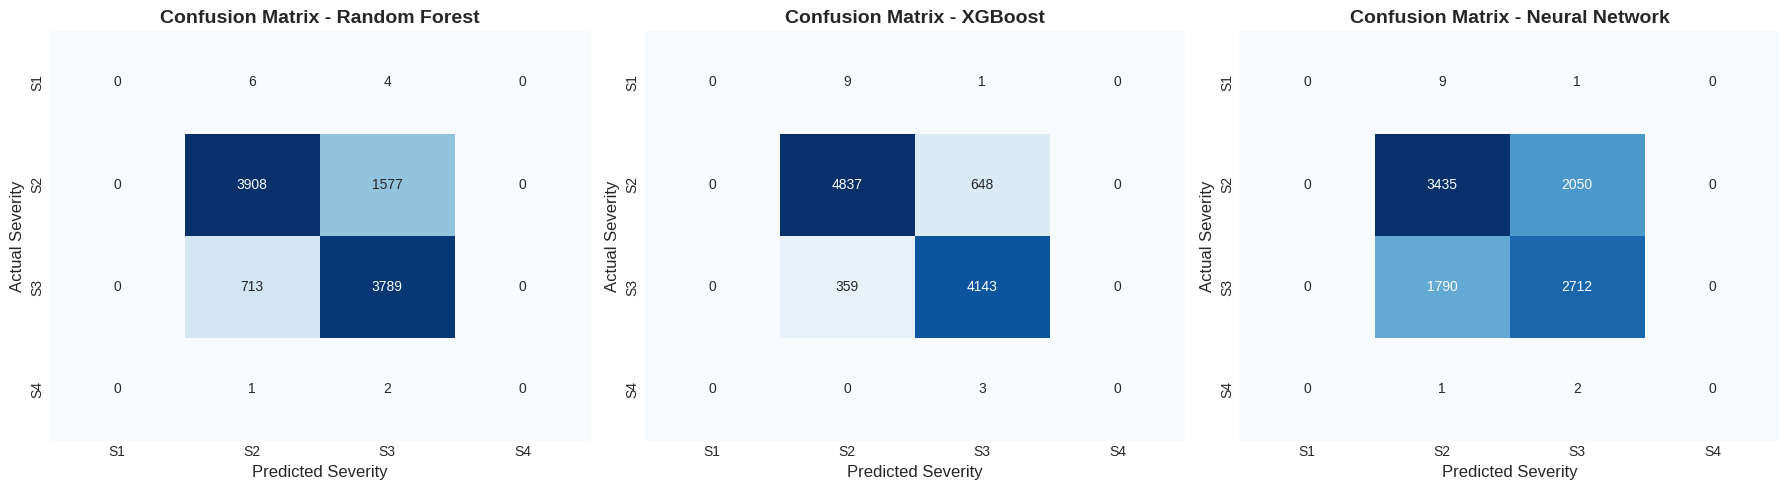

Confusion matrices saved to 'confusion_matrices.png'


In [11]:
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['Random Forest', 'XGBoost', 'Neural Network']
cm_list = [cm_rf, cm_xgb, cm_nn]

for i, (ax, cm, name) in enumerate(zip(axes, cm_list, models)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['S1', 'S2', 'S3', 'S4'],
                yticklabels=['S1', 'S2', 'S3', 'S4'],
                ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Severity', fontsize=12)
    ax.set_ylabel('Actual Severity', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrices saved to 'confusion_matrices.png'")

**PART 11: Performance Comparison Bar Chart**

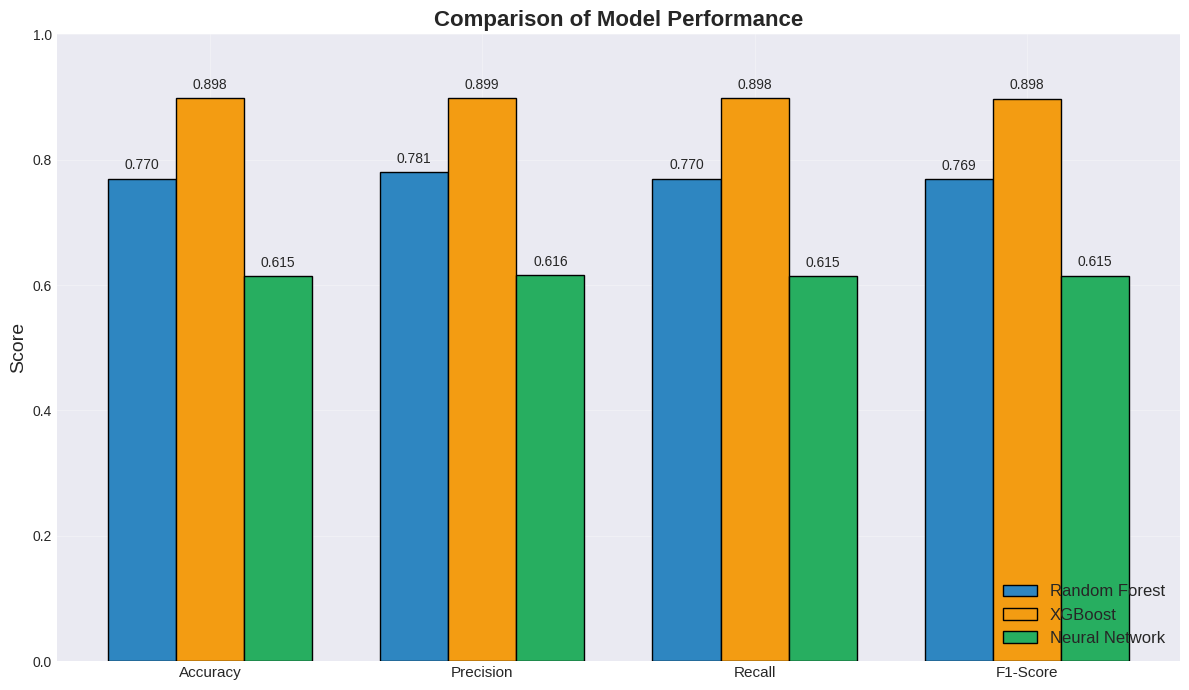

Performance comparison saved to 'performance_comparison.png'


In [12]:
fig, ax = plt.subplots(figsize=(12, 7))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#2E86C1', '#F39C12', '#27AE60']

# Plot bars
bars1 = ax.bar(x - width, comparison_df.iloc[0][1:5], width,
               label='Random Forest', color=colors[0], edgecolor='black', linewidth=1)
bars2 = ax.bar(x, comparison_df.iloc[1][1:5], width,
               label='XGBoost', color=colors[1], edgecolor='black', linewidth=1)
bars3 = ax.bar(x + width, comparison_df.iloc[2][1:5], width,
               label='Neural Network', color=colors[2], edgecolor='black', linewidth=1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Score', fontsize=14)
ax.set_title('Comparison of Model Performance', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(loc='lower right', fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Performance comparison saved to 'performance_comparison.png'")

**PART 12: Feature Importance Visualization**

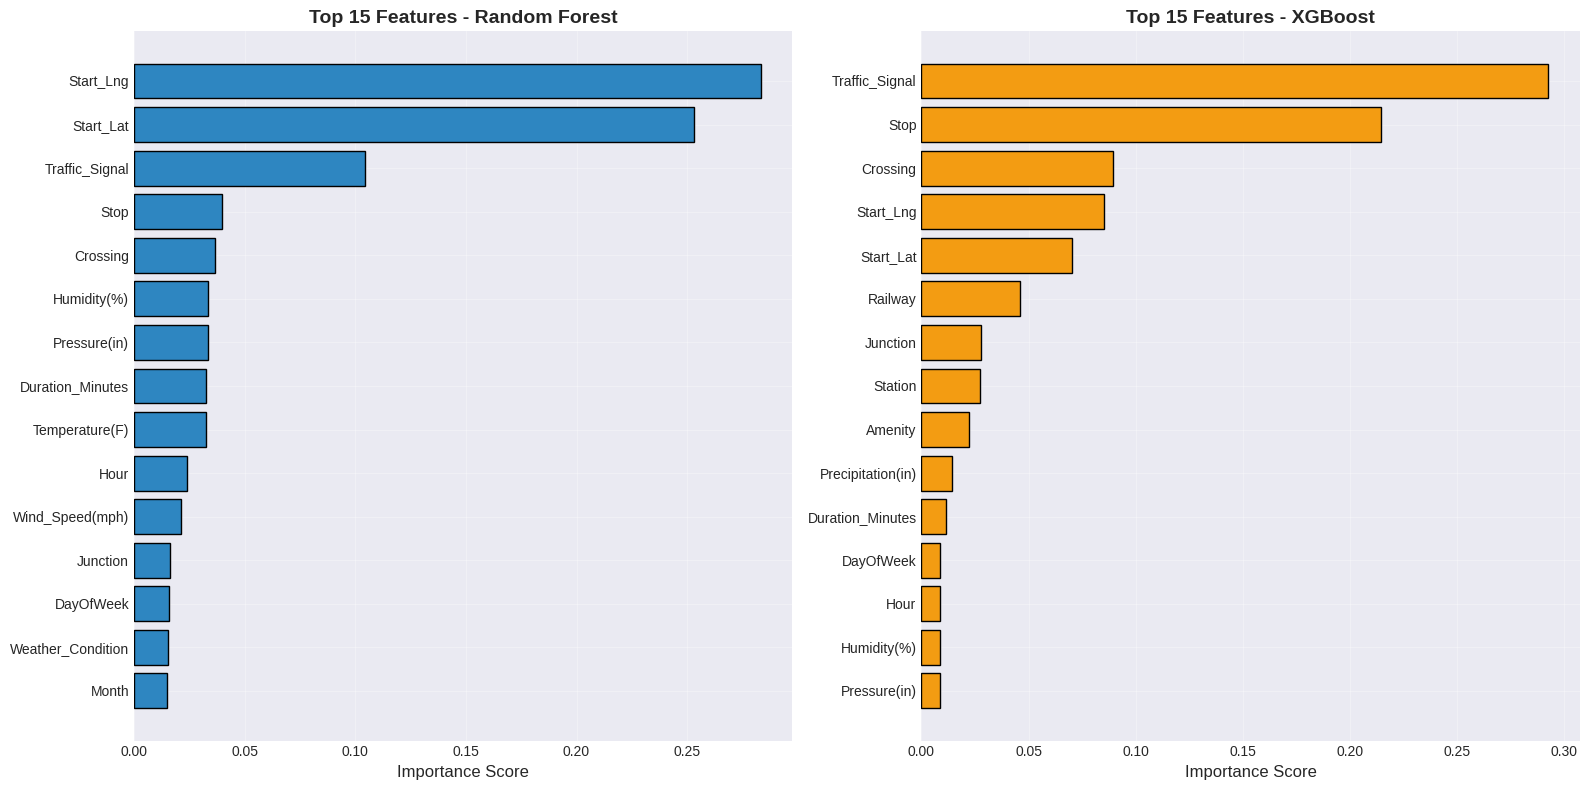

Feature importance saved to 'feature_importance.png'


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[0].barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'],
             color='#2E86C1', edgecolor='black')
axes[0].set_title('Top 15 Features - Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].grid(True, alpha=0.3)

# XGBoost
xgb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[1].barh(xgb_feature_importance['Feature'], xgb_feature_importance['Importance'],
             color='#F39C12', edgecolor='black')
axes[1].set_title('Top 15 Features - XGBoost', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Feature importance saved to 'feature_importance.png'")

**PART 13: Exploratory Data Analysis (EDA) Visualization**

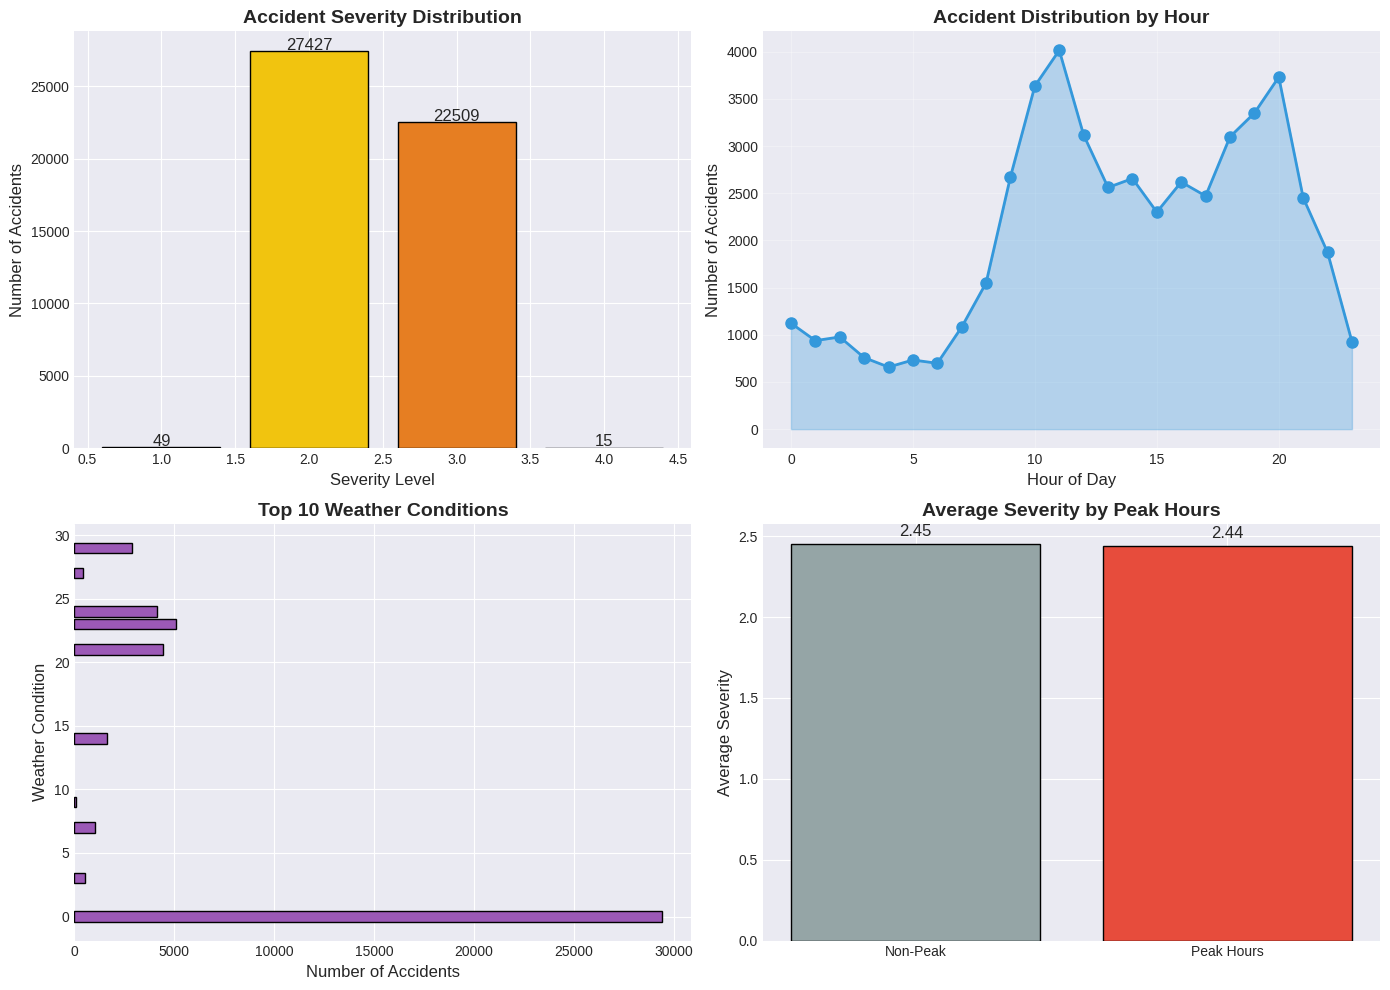

EDA visualizations saved to 'exploratory_analysis.png'


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Severity distribution
severity_counts = y.value_counts().sort_index()
axes[0, 0].bar(severity_counts.index, severity_counts.values,
               color=['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C'],
               edgecolor='black', linewidth=1)
axes[0, 0].set_title('Accident Severity Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Severity Level', fontsize=12)
axes[0, 0].set_ylabel('Number of Accidents', fontsize=12)
for i, v in enumerate(severity_counts.values):
    axes[0, 0].text(i+1, v + 100, str(v), ha='center', fontsize=12)

# Hour distribution
if 'Hour' in df_clean.columns:
    hour_counts = df_clean['Hour'].value_counts().sort_index()
    axes[0, 1].plot(hour_counts.index, hour_counts.values, marker='o', color='#3498DB',
                    linewidth=2, markersize=8)
    axes[0, 1].set_title('Accident Distribution by Hour', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Hour of Day', fontsize=12)
    axes[0, 1].set_ylabel('Number of Accidents', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].fill_between(hour_counts.index, 0, hour_counts.values, alpha=0.3, color='#3498DB')

# Weather conditions
if 'Weather_Condition' in df_clean.columns:
    weather_counts = df_clean['Weather_Condition'].value_counts().head(10)
    axes[1, 0].barh(weather_counts.index, weather_counts.values,
                    color='#9B59B6', edgecolor='black', linewidth=1)
    axes[1, 0].set_title('Top 10 Weather Conditions', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Accidents', fontsize=12)
    axes[1, 0].set_ylabel('Weather Condition', fontsize=12)

# Severity by peak hours
if 'Is_Peak_Hour' in df_clean.columns:
    peak_hour_accidents = df_clean.groupby('Is_Peak_Hour')['Severity'].mean()
    axes[1, 1].bar(['Non-Peak', 'Peak Hours'], peak_hour_accidents.values,
                   color=['#95A5A6', '#E74C3C'], edgecolor='black', linewidth=1)
    axes[1, 1].set_title('Average Severity by Peak Hours', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Average Severity', fontsize=12)
    for i, v in enumerate(peak_hour_accidents.values):
        axes[1, 1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('exploratory_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("EDA visualizations saved to 'exploratory_analysis.png'")

**PART 14: Download Results to Local Computer**

In [15]:
print("\n" + "="*60)
print("DOWNLOADING RESULTS")
print("="*60)

from google.colab import files

# Download all files
try:
    files.download('model_comparison_results.csv')
    print("Downloaded: model_comparison_results.csv")
except:
    print("Could not download comparison table")

try:
    files.download('confusion_matrices.png')
    print("Downloaded: confusion_matrices.png")
except:
    print("Could not download confusion matrices")

try:
    files.download('performance_comparison.png')
    print("Downloaded: performance_comparison.png")
except:
    print("Could not download performance comparison")

try:
    files.download('feature_importance.png')
    print("Downloaded: feature_importance.png")
except:
    print("Could not download feature importance")

try:
    files.download('exploratory_analysis.png')
    print("Downloaded: exploratory_analysis.png")
except:
    print("Could not download EDA")


DOWNLOADING RESULTS


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: model_comparison_results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: exploratory_analysis.png


**PART 15: Final Project Summary**

In [16]:
print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

print(f"""
PROJECT SUMMARY
{'='*60}
 Dataset: US Accidents (March 2023)
 Total Records: {len(df):,}
 Sample Used: {len(df_sample):,}
 Features: {X.shape[1]}
 Target: Severity (1-4)

 MODELS PERFORMANCE
{'='*60}
 Random Forest:
   - Accuracy:  {rf_accuracy:.4f}
   - F1-Score:  {rf_f1:.4f}

 XGBoost:
   - Accuracy:  {xgb_accuracy:.4f}
   - F1-Score:  {xgb_f1:.4f}

 Neural Network:
   - Accuracy:  {nn_accuracy:.4f}
   - F1-Score:  {nn_f1:.4f}

 Best Model: {best_model['Model']} with {best_model['Accuracy']:.4f} accuracy

 OUTPUT FILES GENERATED:
{'='*60}
1. model_comparison_results.csv  - Performance comparison table
2. confusion_matrices.png        - Confusion matrices for all models
3. performance_comparison.png    - Bar chart comparison
4. feature_importance.png        - Feature importance visualization
5. exploratory_analysis.png      - EDA visualizations

 All files have been downloaded to your computer!
""")


PROJECT COMPLETED SUCCESSFULLY!

PROJECT SUMMARY
 Dataset: US Accidents (March 2023)
 Total Records: 100,000
 Sample Used: 50,000
 Features: 29
 Target: Severity (1-4)

 MODELS PERFORMANCE
 Random Forest:
   - Accuracy:  0.7697
   - F1-Score:  0.7694

 XGBoost:
   - Accuracy:  0.8980
   - F1-Score:  0.8976

 Neural Network:
   - Accuracy:  0.6147
   - F1-Score:  0.6150

 Best Model: XGBoost with 0.8980 accuracy

 OUTPUT FILES GENERATED:
1. model_comparison_results.csv  - Performance comparison table
2. confusion_matrices.png        - Confusion matrices for all models
3. performance_comparison.png    - Bar chart comparison
4. feature_importance.png        - Feature importance visualization
5. exploratory_analysis.png      - EDA visualizations

 All files have been downloaded to your computer!

